# Retail Transactions Analysis

**Dataset:** Retail Transactions Dataset  
**Objective:** Exploratory Data Analysis (EDA) to identify sales patterns, customer behavior, and payment preferences.  
**Source:** `Retail_Transactions_Dataset.csv`


In [2]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv("Retail_Transactions_Dataset.csv")

dataset.head()


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


## EDA

### Understanding the dataset


In [ ]:
## understanding dataset
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  str    
 2   Customer_Name      1000000 non-null  str    
 3   Product            1000000 non-null  str    
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  str    
 7   City               1000000 non-null  str    
 8   Store_Type         1000000 non-null  str    
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  str    
 11  Season             1000000 non-null  str    
 12  Promotion          666057 non-null   str    
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 92.5 MB


### Total items sold


In [3]:
## total values
total_values_sold = dataset["Total_Cost"].sum()

total_values_sold

np.float64(52455220.400000006)

In [ ]:
dataset["Store_Type"].unique()


<bound method Series.unique of 0            Warehouse Club
1           Specialty Store
2          Department Store
3                  Pharmacy
4           Specialty Store
                ...        
999995          Supermarket
999996       Warehouse Club
999997    Convenience Store
999998          Supermarket
999999             Pharmacy
Name: Store_Type, Length: 1000000, dtype: str>

### Total sales by store type


In [5]:
store_type = dataset.groupby("Store_Type")["Total_Items"].sum()

store_type

Store_Type
Convenience Store    918049
Department Store     915635
Pharmacy             917729
Specialty Store      914950
Supermarket          915772
Warehouse Club       913806
Name: Total_Items, dtype: int64

### Items sold per store type and percentage of total


In [4]:
## how much represents in percentage of total sold items
store_type = dataset.groupby("Store_Type")["Total_Items"].sum()

total_sold_items = dataset["Total_Items"].sum()

percentage = (store_type / total_sold_items) * 100

df_percentage = pd.DataFrame({
    "Total_Items": store_type,
    "Percentage": percentage
})

df_percentage

,Total_Items,Percentage
Store_Type,,
Convenience Store,918049,16.704128
Department Store,915635,16.660204
Pharmacy,917729,16.698305
Specialty Store,914950,16.647741
Supermarket,915772,16.662697
Warehouse Club,913806,16.626925


### Total cost per store type and percentage of total costs


In [ ]:
total_costs = dataset["Total_Cost"].sum()

total_costs_group = dataset.groupby("Store_Type")["Total_Cost"].sum()
percentage_costs = (total_costs_group / total_costs) * 100

df_costs_percentage = pd.DataFrame({
    "Total_Cost": total_costs_group,
    "Percentage": percentage_costs
})

df_costs_percentage

,Total_Cost,Percentage
Store_Type,,
Convenience Store,8731901.36,16.646392
Department Store,8731555.57,16.645732
Pharmacy,8766679.01,16.712691
Specialty Store,8701600.22,16.588626
Supermarket,8763455.21,16.706545
Warehouse Club,8760029.03,16.700014


### Most and least used payment methods


In [8]:
## most and less used payments
payments_methods = dataset["Payment_Method"].value_counts()

payments_methods

Payment_Method
Cash              250230
Debit Card        250074
Credit Card       249985
Mobile Payment    249711
Name: count, dtype: int64

### Most common payment method per cost range


In [9]:
## most used method for most expensive purchases
most_used_payment = dataset["Payment_Method"].value_counts()

most_used_payment

Payment_Method
Cash              250230
Debit Card        250074
Credit Card       249985
Mobile Payment    249711
Name: count, dtype: int64

In [6]:
# Create cost ranges to find the most common payment method per range
bins = [10, 40, 80, 100]
labels = ["10-40", "40-80", "80+"]

dataset["Cost_Range"] = pd.cut(dataset["Total_Cost"],
                               bins=bins,
                               labels=labels,
                               right=True)
dataset["Cost_Range"]


0         40-80
1         10-40
2         40-80
3         10-40
4         10-40
          ...  
999995    10-40
999996      80+
999997    40-80
999998    10-40
999999    40-80
Name: Cost_Range, Length: 1000000, dtype: category
Categories (3, str): ['10-40' < '40-80' < '80+']

In [ ]:
# Find the most common payment method per cost range
result = dataset.groupby("Cost_Range")["Payment_Method"].agg(
    lambda x: x.value_counts().idxmax())

result


Cost_Range
10-40     Debit Card
40-80           Cash
80+      Credit Card
Name: Payment_Method, dtype: str

### Number of sales per hour


In [ ]:
# Number of sales per hour
new_date = pd.to_datetime(dataset["Date"])

hour_labels = [
    "00:00-01:00", "01:00-02:00", "02:00-03:00", "03:00-04:00", "04:00-05:00",
    "05:00-06:00", "06:00-07:00", "07:00-08:00", "08:00-09:00", "09:00-10:00",
    "10:00-11:00", "11:00-12:00", "12:00-13:00", "13:00-14:00", "14:00-15:00",
    "15:00-16:00", "16:00-17:00", "17:00-18:00", "18:00-19:00", "19:00-20:00",
    "20:00-21:00", "21:00-22:00", "22:00-23:00", "23:00-00:00"
]

## extract hour from each item
new_date_hour_item = new_date.dt.hour

## group by hour and count items sold per hour
sales_per_hour = dataset.groupby(new_date_hour_item)["Total_Items"].count()

# Adjust index to display hour labels
sales_per_hour.index = hour_labels

# Sort sales per hour in descending order
sales_per_hour = sales_per_hour.sort_values(ascending=False)

sales_per_hour


10:00-11:00    42021
08:00-09:00    41926
03:00-04:00    41917
21:00-22:00    41894
18:00-19:00    41843
09:00-10:00    41841
15:00-16:00    41819
13:00-14:00    41817
12:00-13:00    41790
04:00-05:00    41768
14:00-15:00    41739
23:00-00:00    41698
20:00-21:00    41674
17:00-18:00    41655
19:00-20:00    41646
02:00-03:00    41617
05:00-06:00    41574
07:00-08:00    41521
06:00-07:00    41508
16:00-17:00    41505
22:00-23:00    41433
00:00-01:00    41416
01:00-02:00    41224
11:00-12:00    41154
Name: Total_Items, dtype: int64

### Peak selling period during the day


In [ ]:
## calculate the period with the highest sales (dawn, morning, afternoon, night)
labels = ["Dawn", "Morning", "Afternoon", "Night"]
bins = [0, 6, 12, 18, 24]

intervals = pd.cut(new_date.dt.hour, bins=bins, labels=labels)

period = dataset.groupby(intervals)["Total_Items"].sum()

period = period.sort_values(ascending=False)

period


Date
Tarde        1377167
Manhã        1373556
Madrugada    1371198
Noite        1145781
Name: Total_Items, dtype: int64

### Number of sales per day of the week


In [ ]:
## convert to datetime
dataset_week = pd.to_datetime(dataset["Date"])
labels = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday",
    "Sunday"
]

## get each day of the week [0, 1, 2, 3, 4, 5, 6]
days_of_week = dataset_week.dt.day_of_week

## create a series indexed by days_of_week and count occurrences
group_by_days_of_week = dataset.groupby(days_of_week)["Date"].count()

group_by_days_of_week.index = labels

group_by_days_of_week = group_by_days_of_week.sort_values(ascending=False)

group_by_days_of_week


Quinta     143375
Sexta      143367
Sábado     143310
Quarta     143104
Segunda    142435
Terça      142317
Domingo    142092
Name: Date, dtype: int64

### Day and hour with the most sales by city


In [15]:
date_column_to_datetime = pd.to_datetime(dataset["Date"])

date_column_day = date_column_to_datetime.dt.day
date_column_hour = date_column_to_datetime.dt.hour

city = dataset["City"]
sells = dataset["Total_Items"]

city_sells_date_dataframe = pd.DataFrame({
    "City": city,
    "Total_Items": sells,
    "Day": date_column_day,
    "Hour": date_column_hour
})

city_sells_date_dataframe = city_sells_date_dataframe.groupby(
    ["City", "Day", "Hour"], as_index=False)["Total_Items"].sum().sort_values(
        ["Total_Items", "Day", "Hour"], ascending=False)

city_sells_date_dataframe.head(100)

,City,Day,Hour,Total_Items
5349,New York,6,21,1045
93,Atlanta,4,21,1018
1097,Boston,15,17,990
6852,Seattle,7,12,990
4581,Miami,5,21,989
...,...,...,...,...
1766,Chicago,12,14,915
3724,Los Angeles,1,4,915
1953,Chicago,20,9,914
6285,San Francisco,14,21,913


## EDA - Part 2


In [ ]:
dataset_teste = dataset["Store_Type"].unique()

dataset_teste


<bound method Series.unique of 0            Warehouse Club
1           Specialty Store
2          Department Store
3                  Pharmacy
4           Specialty Store
                ...        
999995          Supermarket
999996       Warehouse Club
999997    Convenience Store
999998          Supermarket
999999             Pharmacy
Name: Store_Type, Length: 1000000, dtype: str>

In [ ]:
dataset_store_type = dataset["Store_Type"].unique()

## filter only "Supermarket" rows
df_supermarket = dataset[dataset["Store_Type"] == "Supermarket"].copy()

df_supermarket.head()


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Cost_Range
5,1000000005,2021-10-07 12:37:26,Joshua Frazier,"['Toothpaste', 'Chicken']",3,72.24,Cash,Houston,Supermarket,True,Retiree,Spring,Discount on Selected Items,40-80
32,1000000032,2023-04-04 10:57:09,Robert Gilbert DDS,"['Apple', 'Butter']",7,41.40,Debit Card,Chicago,Supermarket,False,Middle-Aged,Spring,NaN,40-80
34,1000000034,2023-02-07 14:09:36,Stacy Owen,"['Yogurt', 'Ice Cream', 'Insect Repellent']",5,34.27,Credit Card,San Francisco,Supermarket,True,Teenager,Summer,BOGO (Buy One Get One),10-40
39,1000000039,2023-07-11 11:36:26,Donald Bradford,"['Potatoes', 'Air Freshener', 'Sponges', 'Onio...",5,39.08,Cash,Dallas,Supermarket,False,Young Adult,Spring,NaN,10-40
50,1000000050,2021-04-10 19:14:33,Ryan Hammond,"['Hand Sanitizer', 'Plant Fertilizer', 'Baby W...",1,78.46,Mobile Payment,San Francisco,Supermarket,False,Teenager,Summer,Discount on Selected Items,40-80


In [ ]:
unique_products = (df_supermarket["Product"].apply(
    ast.literal_eval).explode().unique())

unique_products


<StringArray>
[               'Toothpaste',                   'Chicken',
                     'Apple',                    'Butter',
                    'Yogurt',                 'Ice Cream',
          'Insect Repellent',                  'Potatoes',
             'Air Freshener',                   'Sponges',
                    'Onions',         'Laundry Detergent',
            'Hand Sanitizer',          'Plant Fertilizer',
                'Baby Wipes',              'Power Strips',
                   'Dustpan',               'Bath Towels',
                   'Pickles',             'Shaving Cream',
               'Canned Soup',                       'Tea',
               'Light Bulbs',                   'Tissues',
                   'Ketchup',                  'Dishware',
                     'Bread',                      'Eggs',
                'Trash Bags', 'Feminine Hygiene Products',
                'Lawn Mower',                    'Razors',
                'Trash Cans',             

In [19]:
most_selled_item = df_supermarket["Product"].apply(ast.literal_eval).explode()

most_selled_item.value_counts()

Product
Toothpaste        11987
Soda               6274
Sponges            6251
Soap               6249
Shampoo            6240
                  ...  
Canned Soup        5982
Toilet Paper       5962
Cleaning Spray     5959
Power Strips       5954
Water              5942
Name: count, Length: 81, dtype: int64

### Most purchased item per customer profile


In [20]:
df_customer_most_selled = most_selled_item.to_frame("Product")

df_customer_most_selled["Customer_Category"] = df_supermarket[
    "Customer_Category"]

df_customer_most_selled

,Product,Customer_Category
5,Toothpaste,Retiree
5,Chicken,Retiree
32,Apple,Middle-Aged
32,Butter,Middle-Aged
34,Yogurt,Teenager
...,...,...
999995,BBQ Sauce,Middle-Aged
999998,Diapers,Retiree
999998,Coffee,Retiree
999998,Coffee,Retiree


In [21]:
most_selled_by_category = df_customer_most_selled.groupby(
    "Customer_Category")["Product"].agg(lambda x: x.value_counts().idxmax())

most_selled_by_category

Customer_Category
Homemaker         Toothpaste
Middle-Aged       Toothpaste
Professional      Toothpaste
Retiree           Toothpaste
Senior Citizen    Toothpaste
Student           Toothpaste
Teenager          Toothpaste
Young Adult       Toothpaste
Name: Product, dtype: str

### Customer profiles and consumption


In [ ]:
## discover existing customer categories
df_customer_most_selled["Customer_Category"].unique()


<StringArray>
[       'Retiree',    'Middle-Aged',       'Teenager',    'Young Adult',
      'Homemaker',        'Student',   'Professional', 'Senior Citizen']
Length: 8, dtype: str

#### Top 10 most purchased items by retirees (Supermarket)


In [23]:
retiree_df = df_customer_most_selled[
    df_customer_most_selled["Customer_Category"] == "Retiree"]

retiree_df

,Product,Customer_Category
5,Toothpaste,Retiree
5,Chicken,Retiree
129,Rice,Retiree
129,Broom,Retiree
129,Insect Repellent,Retiree
...,...,...
999994,Milk,Retiree
999998,Diapers,Retiree
999998,Coffee,Retiree
999998,Coffee,Retiree


In [ ]:
## check product counts to determine chart scale
retiree_df["Product"].value_counts()


Product
Toothpaste          1543
Jam                  834
Carrots              819
Pasta                817
Insect Repellent     815
                    ... 
Coffee               707
Cheese               704
Cleaning Spray       703
Cereal               701
Banana               697
Name: count, Length: 81, dtype: int64

/tmp/ipykernel_293046/656851313.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_retireee.index, y=top10_retireee.values, palette="Blues_d")


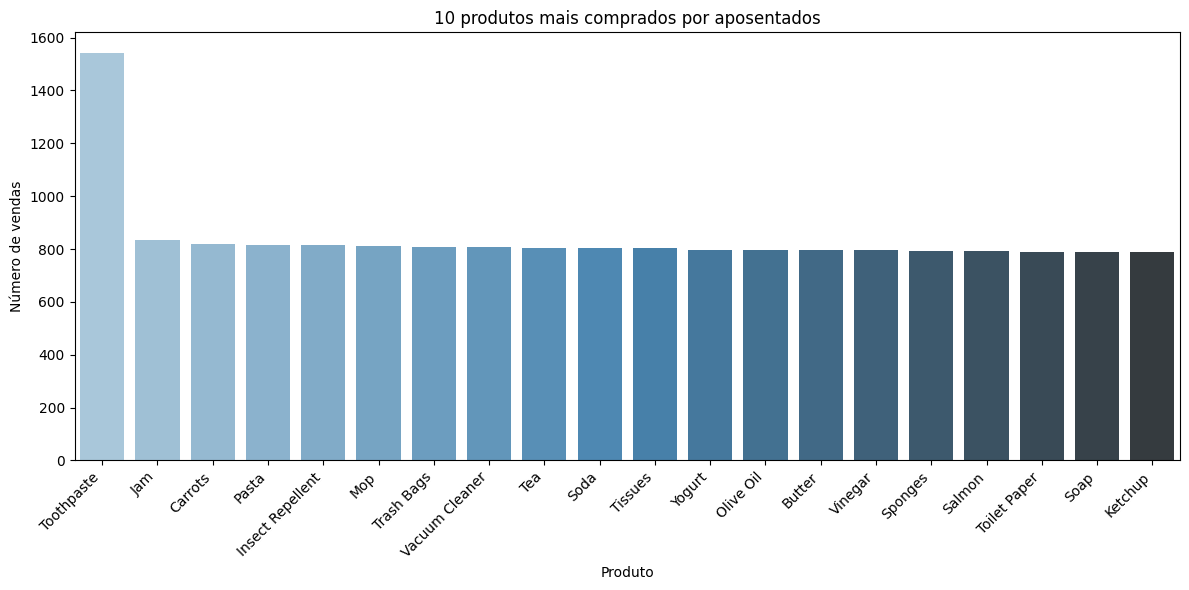

In [ ]:
top10_retireee = retiree_df["Product"].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10_retireee.index, y=top10_retireee.values, palette="Blues_d")

plt.title("Top 10 most purchased items by retirees")
plt.xlabel("Product")
plt.ylabel("Number of sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [26]:
top10_retireee

Product
Toothpaste          1543
Jam                  834
Carrots              819
Pasta                817
Insect Repellent     815
Mop                  813
Trash Bags           808
Vacuum Cleaner       807
Tea                  804
Soda                 804
Tissues              803
Yogurt               798
Olive Oil            797
Butter               795
Vinegar              795
Sponges              793
Salmon               793
Toilet Paper         790
Soap                 790
Ketchup              789
Name: count, dtype: int64

### A Priori Analysis
